# VOIS AICTE Batch1 2026-2027
# Major Project: Seasonal Agriculture Performance Analysis

**Author:** Aditya Bhagour
**Dataset:** `seasonal_agriculture_performance_dataset.csv` (4,000 records, 28 columns)

---

## 1. Introduction to Dataset

The dataset represents agricultural activities carried out across different seasons, geographic areas, and farming practices. It contains information related to farming practices, environmental conditions, crop production, resource usage, and economic performance for 4,000 individual farm records across 8 Indian states, 8 crops, and 3 seasons (Kharif, Rabi, Zaid).

The dataset provides an opportunity to explore how agricultural performance changes across seasons and to identify meaningful patterns and differences through data analysis.

## 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

## 3. Importance of the Problem Statement

Seasonal variations can influence different aspects of agricultural activities and performance. Understanding seasonal patterns through data analytics can help stakeholders:

- Understand variations in agricultural performance
- Identify important seasonal trends
- Compare performance across different periods
- Understand changing environmental conditions
- Examine differences in resource usage
- Identify areas requiring further investigation
- Support evidence-based agricultural planning

For students, this problem provides an opportunity to work on a **focused real-world Data Analytics problem** rather than performing a generic analysis of the entire dataset.

## 4. Objective

The primary objective of this project is to **analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships, and differences in agricultural performance.**

This notebook independently:
- Explores and understands the dataset
- Cleans and prepares the data for analysis
- Examines how agricultural performance varies across seasons
- Identifies important seasonal patterns and trends
- Investigates relationships between seasonal conditions and agricultural outcomes
- Compares relevant groups within different seasons
- Identifies significant differences or unusual patterns
- Applies appropriate statistical and visualization techniques
- Interprets findings based on evidence from the dataset
- Develops meaningful conclusions and data-driven recommendations

## 5. Expected Outcomes

By the end of this project we will:
- Demonstrate an understanding of seasonal agricultural data
- Perform appropriate data cleaning and preparation
- Identify important seasonal patterns
- Compare agricultural performance across seasons
- Discover relationships and variations within the dataset
- Select suitable analytical and visualization techniques independently
- Interpret analytical findings correctly
- Identify significant observations from the data
- Develop evidence-based insights

## 6. Key Questions

This analysis develops and answers its own specific analytical questions, including:

1. How does agricultural performance (yield, production, profit) vary across seasons?
2. What major seasonal patterns can be observed?
3. Which characteristics (rainfall, temperature, water use) change between seasons?
4. What differences exist between agricultural activities (crops, irrigation methods) in different seasons?
5. Are there noticeable variations in resource usage (fertilizer, water, pesticide) across seasons?
6. Are there relationships between seasonal environmental conditions and agricultural performance?
7. How do economic outcomes (cost, revenue, profit) vary across seasons?
8. Are seasonal patterns consistent across different states or crops?
9. Are there unusual or unexpected seasonal patterns (e.g. negative profit)?
10. What conclusions and recommendations can reasonably be drawn from the available data?


## 7. Setup & Data Loading

In [115]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

# If running in Google Colab, upload the CSV first
from google.colab import files
uploaded = files.upload()

import glob

FILE_NAME = glob.glob("seasonal_agriculture_performance_dataset*.csv")[0]
print("Using file:", FILE_NAME)
df = pd.read_csv(FILE_NAME)
print("Shape:", df.shape)
df.head()

Saving seasonal_agriculture_performance_dataset (1).csv to seasonal_agriculture_performance_dataset (1) (2).csv
Using file: seasonal_agriculture_performance_dataset (1).csv
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [79]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [80]:
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,7.10,12.9,108.0,75.8,96.5,Flood,228.2,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,7.66,24.3,97.8,36.7,96.0,Drip,65.9,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,6.33,30.4,149.3,41.8,98.8,Drip,143.0,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,7.57,24.5,118.6,77.5,128.7,Rainfed,116.4,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,7.31,18.9,45.8,79.9,126.7,Flood,242.8,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [81]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [83]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [84]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [85]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 8a. Data Cleaning & Preparation

Explore and understand the dataset, then clean and prepare it for analysis.

In [86]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print("\nPercent missing:")
print((missing / len(df) * 100).round(2))

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Percent missing:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


In [87]:
# Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_ID:", df['Farm_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Farm_ID: 0


In [88]:
# Handle missing values: impute numeric columns with the median,
# grouped by Season so imputed values respect seasonal context
data_df = df.copy()

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    data_df[col] = data_df.groupby("Season")[col].transform(
        lambda s: s.fillna(s.median())
    )

print("Remaining missing values:", data_df.isnull().sum().sum())

Remaining missing values: 0


In [89]:
# Basic sanity checks on categorical fields
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(col, "->", data_df[col].nunique(), "unique values:", sorted(data_df[col].unique()))

State -> 8 unique values: ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District -> 10 unique values: ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop -> 8 unique values: ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season -> 3 unique values: ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method -> 4 unique values: ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [90]:
# Flag: many records show negative Profit_INR - not a data error, but a real
# pattern worth investigating later in this analysis
neg_profit_pct = (data_df["Profit_INR"] < 0).mean() * 100
print(f"Records with negative profit: {neg_profit_pct:.1f}%")

Records with negative profit: 49.1%


In [91]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


## 8b. Outlier Investigation

Checking for extreme values in key numeric fields using the IQR (Interquartile Range) method, so outliers are explicitly identified and discussed rather than only appearing incidentally in later boxplots.

In [122]:
data_df = df.copy()
cols_to_fill = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
data_df[cols_to_fill] = data_df.groupby("Season")[cols_to_fill].transform(lambda s: s.fillna(s.median()))

outlier_cols = ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR", "Rainfall_mm", "Water_Used_m3", "Fertilizer_kg_ha"]
q1 = data_df[outlier_cols].quantile(0.25)
q3 = data_df[outlier_cols].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_counts = ((data_df[outlier_cols] < lower_bound) | (data_df[outlier_cols] > upper_bound)).sum()
outlier_pct = (outlier_counts / len(data_df) * 100).round(1)

print("Outlier counts (IQR method):")
print(outlier_counts)
print()
print("Outlier percentage:")
print(outlier_pct)

Outlier counts (IQR method):
Yield_Tonnes_Ha      302
Production_Tonnes    333
Profit_INR           404
Rainfall_mm            0
Water_Used_m3        276
Fertilizer_kg_ha      15
dtype: int64

Outlier percentage:
Yield_Tonnes_Ha       7.6
Production_Tonnes     8.3
Profit_INR           10.1
Rainfall_mm           0.0
Water_Used_m3         6.9
Fertilizer_kg_ha      0.4
dtype: float64


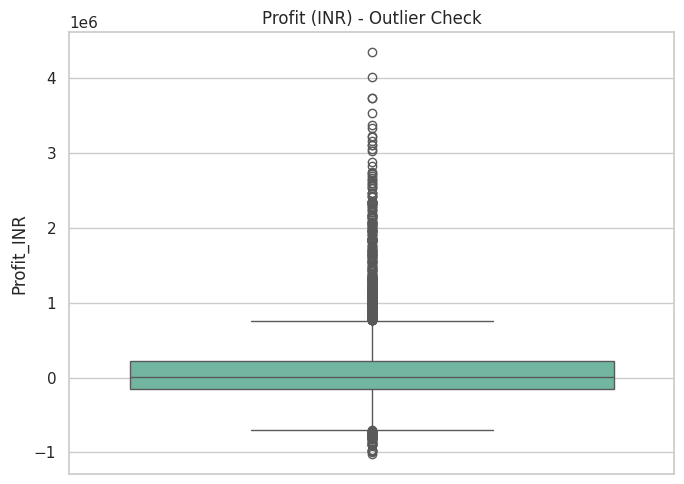

Note: 49.1% of records show negative profit — these are not
data errors, but a genuine pattern investigated further in later sections.


In [121]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=data_df, y="Profit_INR")
plt.title("Profit (INR) - Outlier Check")
plt.tight_layout()
plt.show()

neg_profit_pct = (data_df["Profit_INR"] < 0).mean() * 100
print(f"Note: {neg_profit_pct:.1f}% of records show negative profit — these are not")
print("data errors, but a genuine pattern investigated further in later sections.")

## 9. Univariate Analysis

Examining individual variables — categorical distribution, numerical spread, and seasonal split.

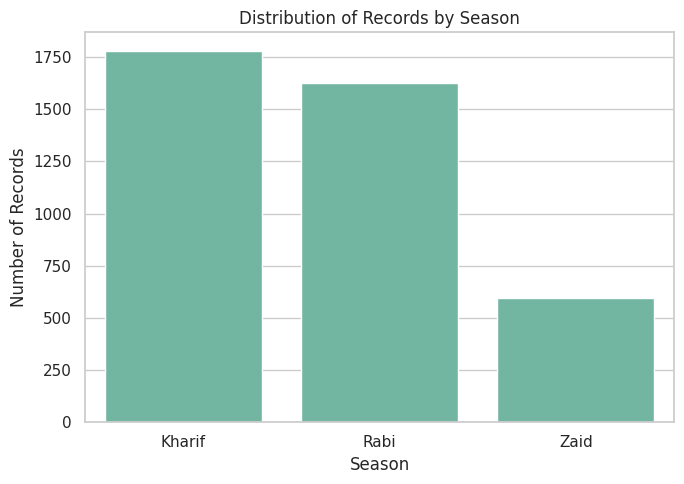

In [92]:
# Categorical: distribution of records by Season
plt.figure(figsize=(7, 5))
sns.countplot(data=data_df, x="Season", order=data_df["Season"].value_counts().index)
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

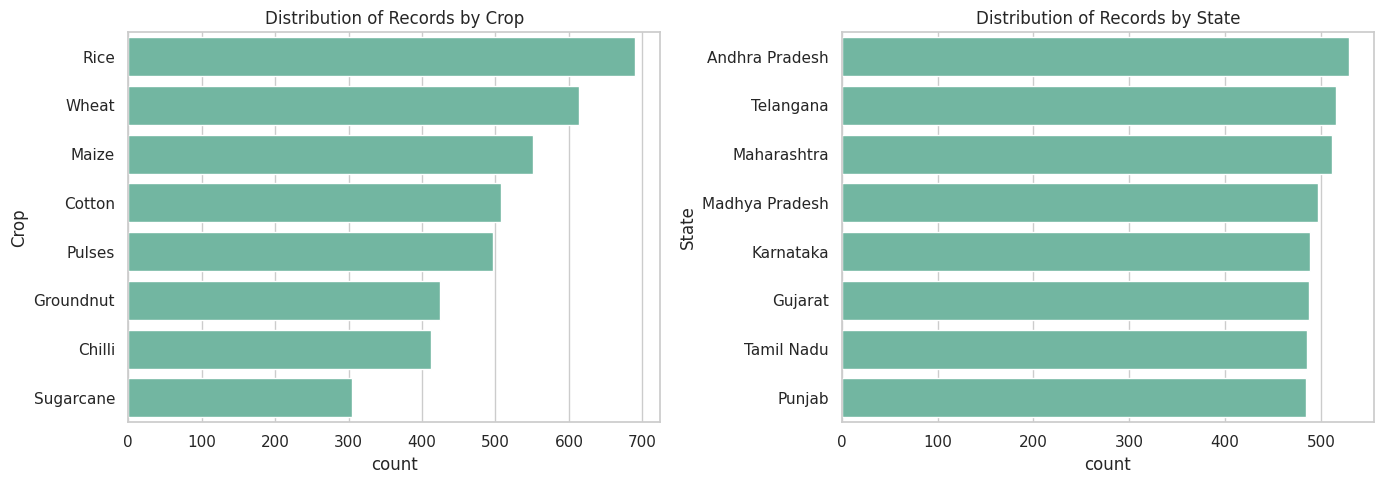

In [93]:
# Categorical: Crop and State distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=data_df, y="Crop", order=data_df["Crop"].value_counts().index, ax=axes[0])
axes[0].set_title("Distribution of Records by Crop")
sns.countplot(data=data_df, y="State", order=data_df["State"].value_counts().index, ax=axes[1])
axes[1].set_title("Distribution of Records by State")
plt.tight_layout()
plt.show()

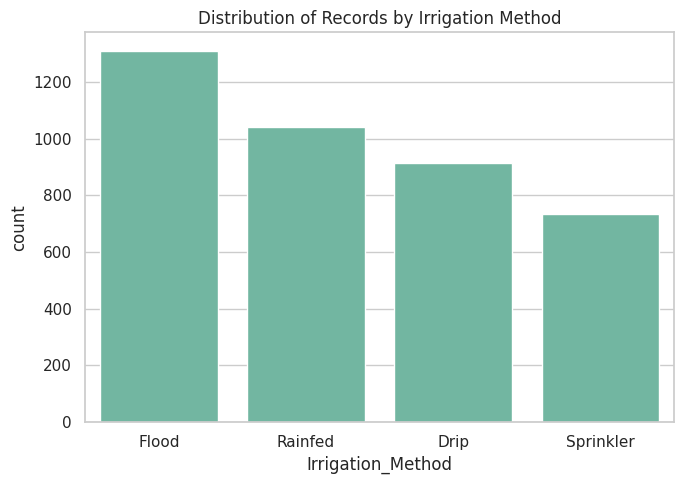

In [94]:
# Categorical: Irrigation method distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=data_df, x="Irrigation_Method", order=data_df["Irrigation_Method"].value_counts().index)
plt.title("Distribution of Records by Irrigation Method")
plt.tight_layout()
plt.show()

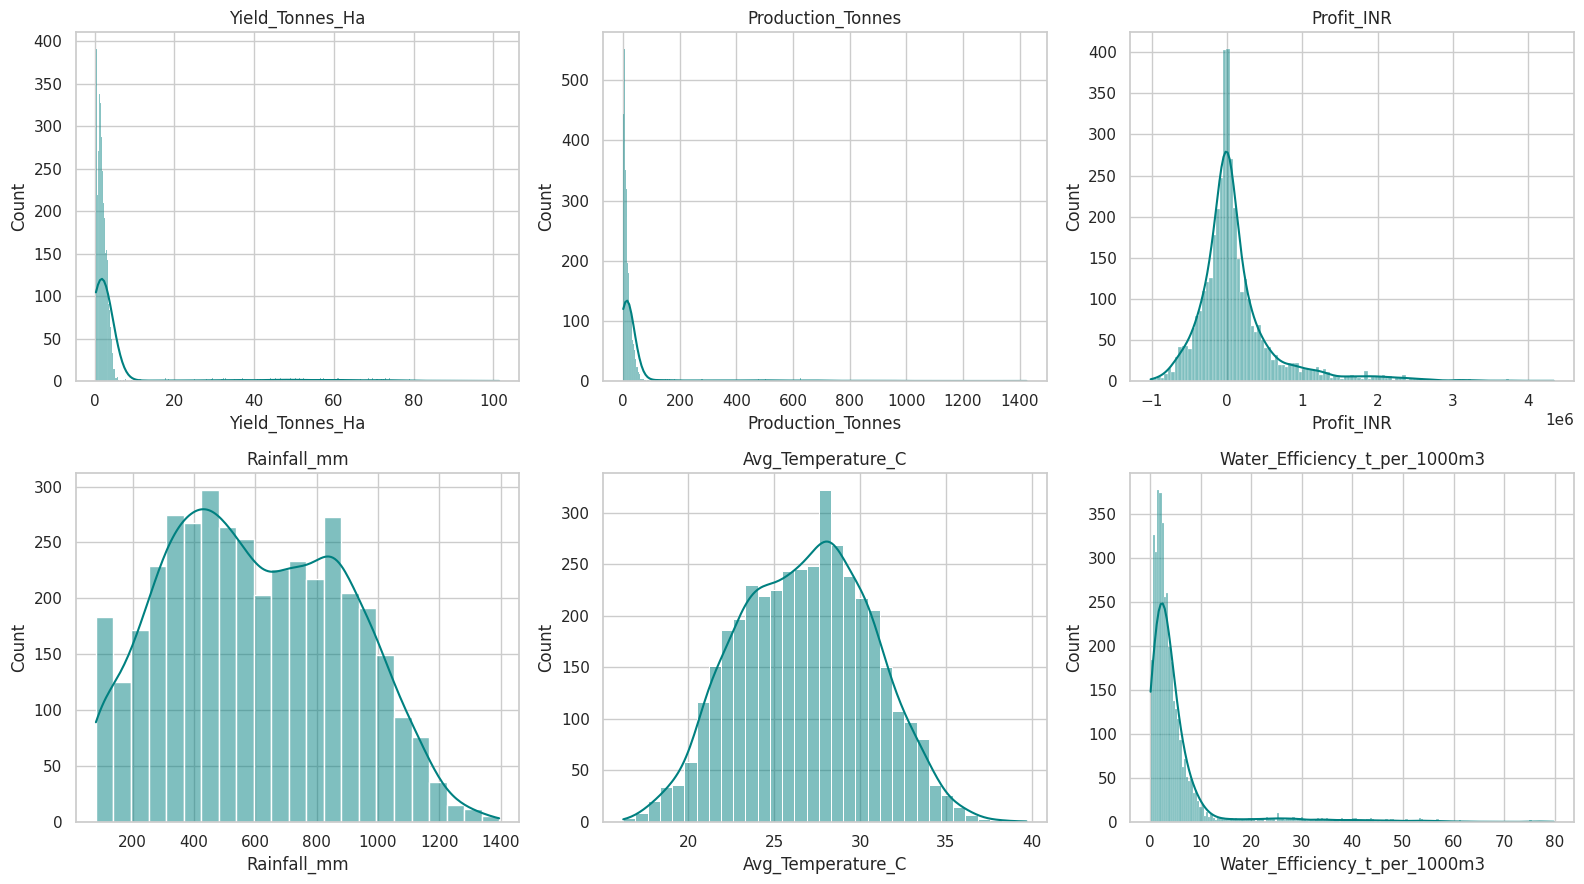

In [95]:
# Numerical: distributions of key performance metrics
num_cols = ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR",
            "Rainfall_mm", "Avg_Temperature_C", "Water_Efficiency_t_per_1000m3"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(data_df[col], kde=True, ax=ax, color="teal")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 10. Seasonal Performance Comparison (Bivariate Analysis)

Comparing key performance and environmental metrics across the three seasons.

In [96]:
metrics = ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR", "Total_Cost_INR",
           "Revenue_INR", "Rainfall_mm", "Avg_Temperature_C",
           "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"]

season_summary = data_df.groupby("Season")[metrics].mean().round(2)
season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Total_Cost_INR,Revenue_INR,Rainfall_mm,Avg_Temperature_C,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,5.63,46.31,178914.65,531804.41,710719.06,852.11,28.45,5.89,54.47
Rabi,5.04,41.49,87689.47,513836.58,601526.05,435.94,23.49,5.19,40.48
Zaid,4.64,38.89,-24804.82,543976.73,519171.90,299.12,31.04,4.41,38.22


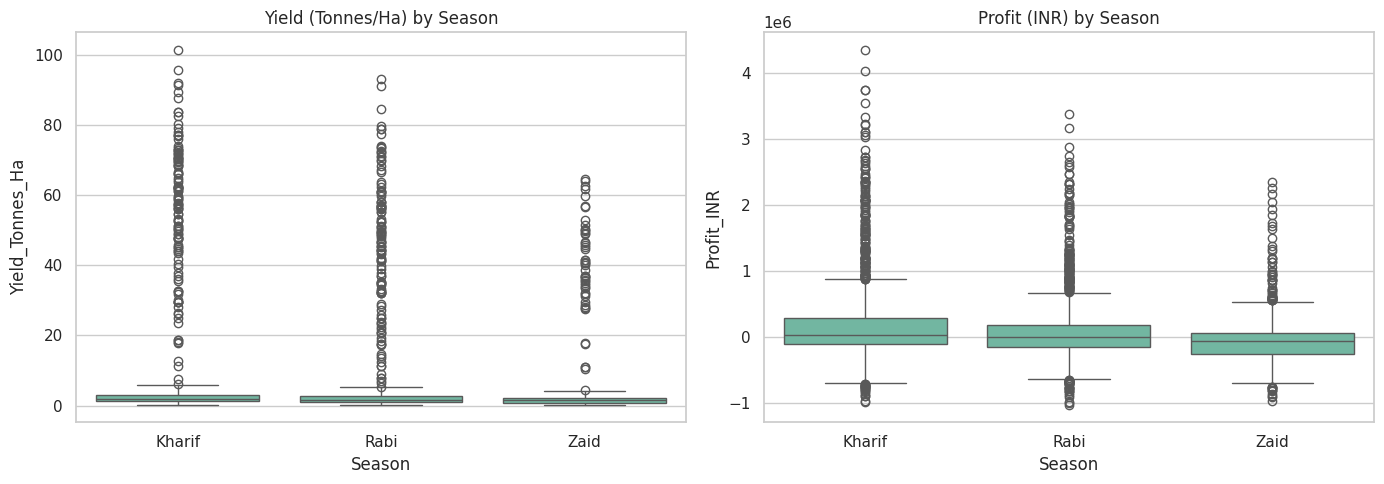

In [97]:
# Boxplots: Yield and Profit across seasons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data_df, x="Season", y="Yield_Tonnes_Ha", ax=axes[0])
axes[0].set_title("Yield (Tonnes/Ha) by Season")
sns.boxplot(data=data_df, x="Season", y="Profit_INR", ax=axes[1])
axes[1].set_title("Profit (INR) by Season")
plt.tight_layout()
plt.show()

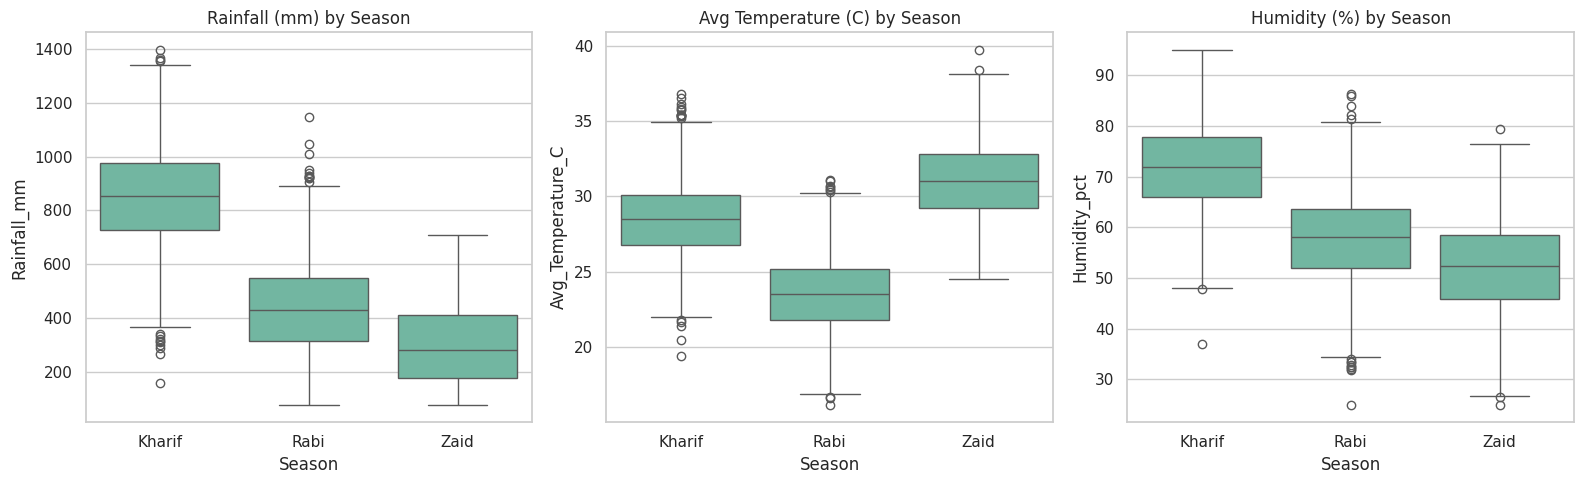

In [98]:
# Boxplots: Environmental conditions across seasons
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=data_df, x="Season", y="Rainfall_mm", ax=axes[0])
axes[0].set_title("Rainfall (mm) by Season")
sns.boxplot(data=data_df, x="Season", y="Avg_Temperature_C", ax=axes[1])
axes[1].set_title("Avg Temperature (C) by Season")
sns.boxplot(data=data_df, x="Season", y="Humidity_pct", ax=axes[2])
axes[2].set_title("Humidity (%) by Season")
plt.tight_layout()
plt.show()

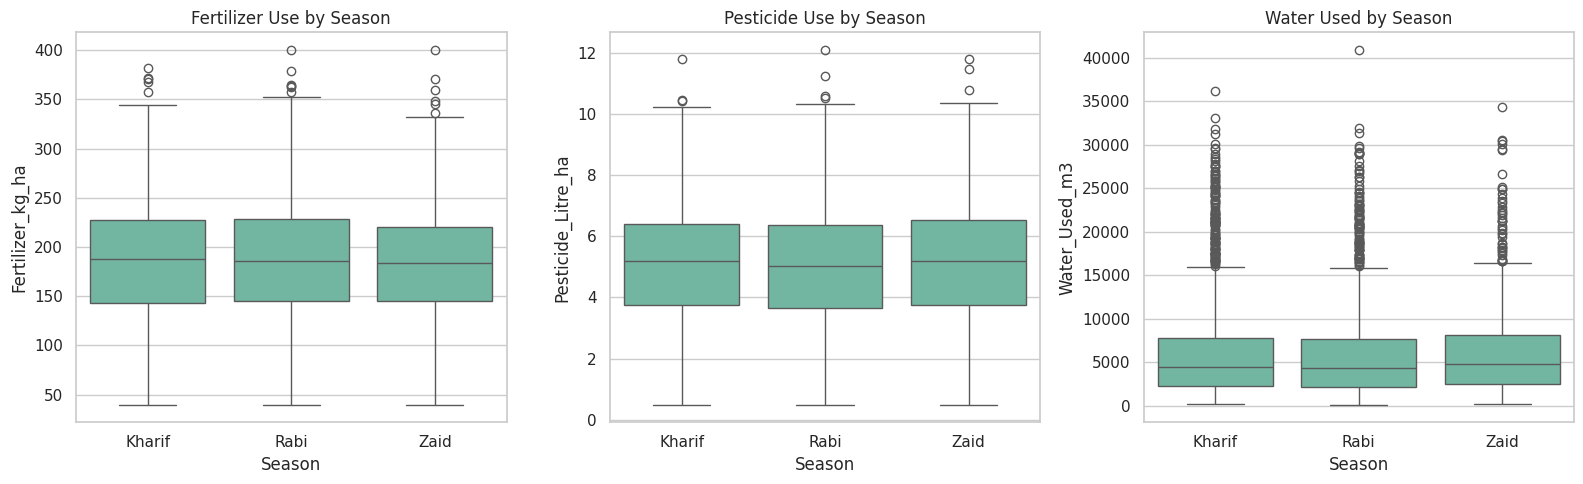

In [99]:
# Resource usage across seasons: fertilizer, pesticide, water
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=data_df, x="Season", y="Fertilizer_kg_ha", ax=axes[0])
axes[0].set_title("Fertilizer Use by Season")
sns.boxplot(data=data_df, x="Season", y="Pesticide_Litre_ha", ax=axes[1])
axes[1].set_title("Pesticide Use by Season")
sns.boxplot(data=data_df, x="Season", y="Water_Used_m3", ax=axes[2])
axes[2].set_title("Water Used by Season")
plt.tight_layout()
plt.show()

In [100]:
# Irrigation method mix within each season
irrigation_by_season = pd.crosstab(data_df["Season"], data_df["Irrigation_Method"], normalize="index") * 100
irrigation_by_season.round(1)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


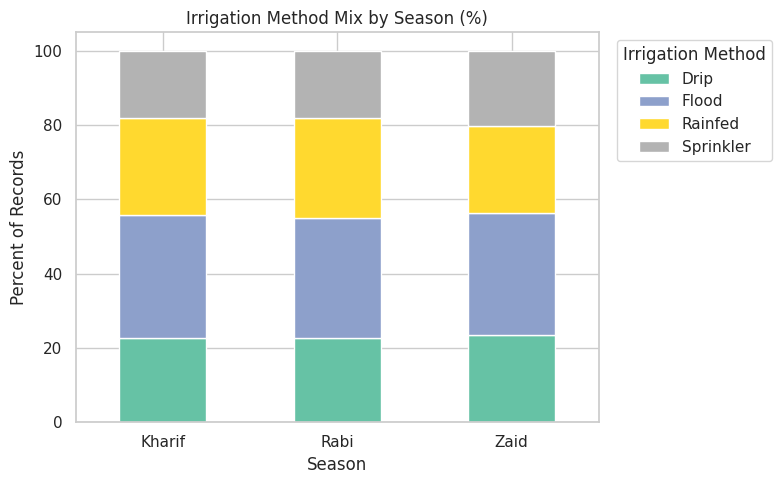

In [101]:
irrigation_by_season.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Irrigation Method Mix by Season (%)")
plt.ylabel("Percent of Records")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Relationships Between Variables (Correlation Analysis)

Investigating relationships between environmental conditions and agricultural outcomes.

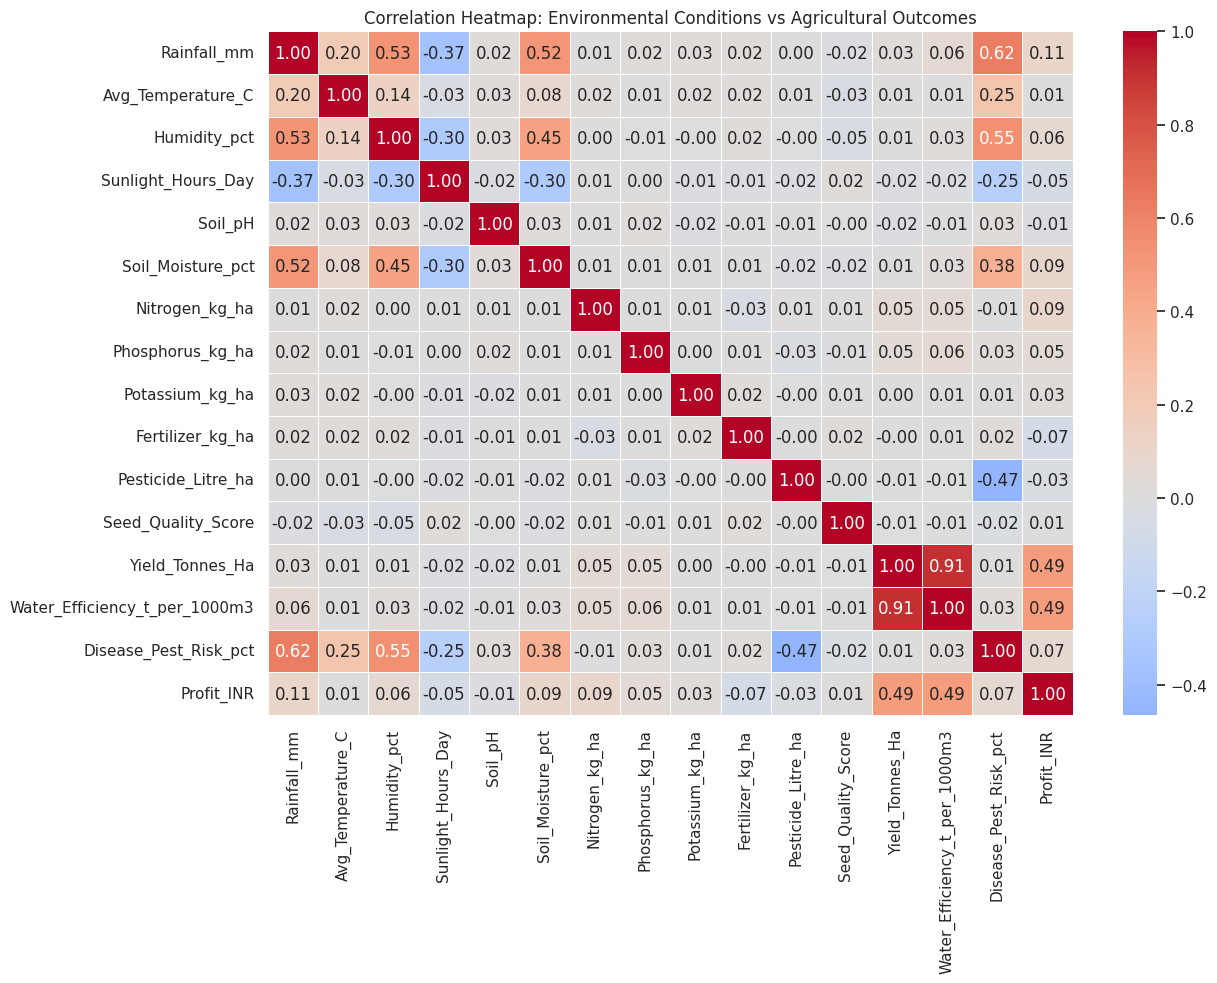

In [102]:
corr_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
             "Soil_pH", "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
             "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
             "Seed_Quality_Score", "Yield_Tonnes_Ha", "Water_Efficiency_t_per_1000m3",
             "Disease_Pest_Risk_pct", "Profit_INR"]

corr_matrix = data_df[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap: Environmental Conditions vs Agricultural Outcomes")
plt.tight_layout()
plt.show()

In [103]:
# Strongest correlations with Yield specifically
yield_corr = corr_matrix["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(key=abs, ascending=False)
print("Correlation of each variable with Yield_Tonnes_Ha:")
yield_corr

Correlation of each variable with Yield_Tonnes_Ha:


,Yield_Tonnes_Ha
Water_Efficiency_t_per_1000m3,0.912561
Profit_INR,0.488459
Nitrogen_kg_ha,0.053167
Phosphorus_kg_ha,0.047974
Rainfall_mm,0.028836
Soil_pH,-0.020691
Sunlight_Hours_Day,-0.015362
Disease_Pest_Risk_pct,0.014351
Humidity_pct,0.012337
Soil_Moisture_pct,0.011101


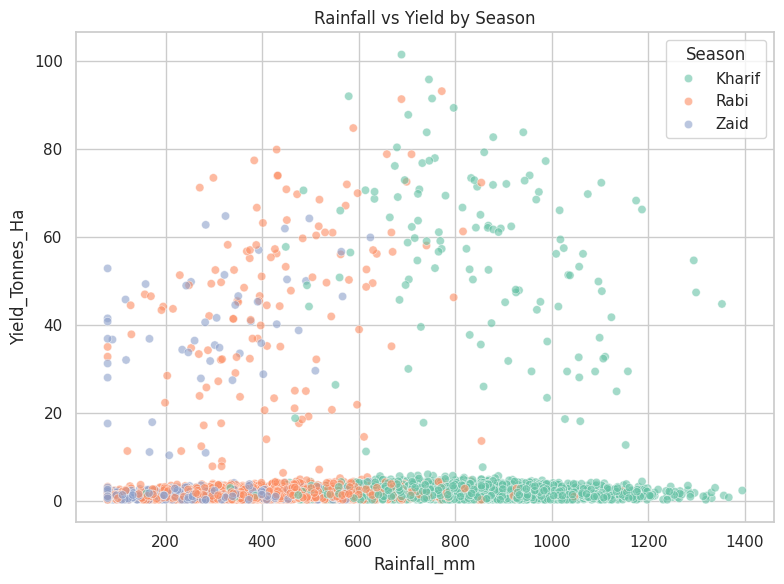

In [104]:
# Scatter: Rainfall vs Yield, colored by Season
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6)
plt.title("Rainfall vs Yield by Season")
plt.tight_layout()
plt.show()

## 12. Statistical Significance of Seasonal Differences

Testing whether the observed differences in Yield across seasons are statistically significant,
using a one-way ANOVA (comparing means of 3+ independent groups).

In [105]:
groups = [data_df.loc[data_df["Season"] == s, "Yield_Tonnes_Ha"] for s in data_df["Season"].unique()]
f_stat, p_value = stats.f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in Yield across seasons (p < 0.05).")
else:
    print("Result: No statistically significant difference in Yield across seasons (p >= 0.05).")

ANOVA F-statistic: 1.554
P-value: 0.2116
Result: No statistically significant difference in Yield across seasons (p >= 0.05).


In [106]:
# Same test for Profit across seasons
groups_profit = [data_df.loc[data_df["Season"] == s, "Profit_INR"] for s in data_df["Season"].unique()]
f_stat_p, p_value_p = stats.f_oneway(*groups_profit)
print(f"ANOVA (Profit) F-statistic: {f_stat_p:.3f}, P-value: {p_value_p:.4f}")

ANOVA (Profit) F-statistic: 34.292, P-value: 0.0000


## 13. Multivariate Analysis — Crop and State Patterns Across Seasons

Checking whether seasonal patterns are consistent across different crops and states.

In [107]:
crop_season_yield = data_df.pivot_table(index="Crop", columns="Season",
                                          values="Yield_Tonnes_Ha", aggfunc="mean").round(2)
crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.28,38.42
Wheat,2.25,2.06,1.75


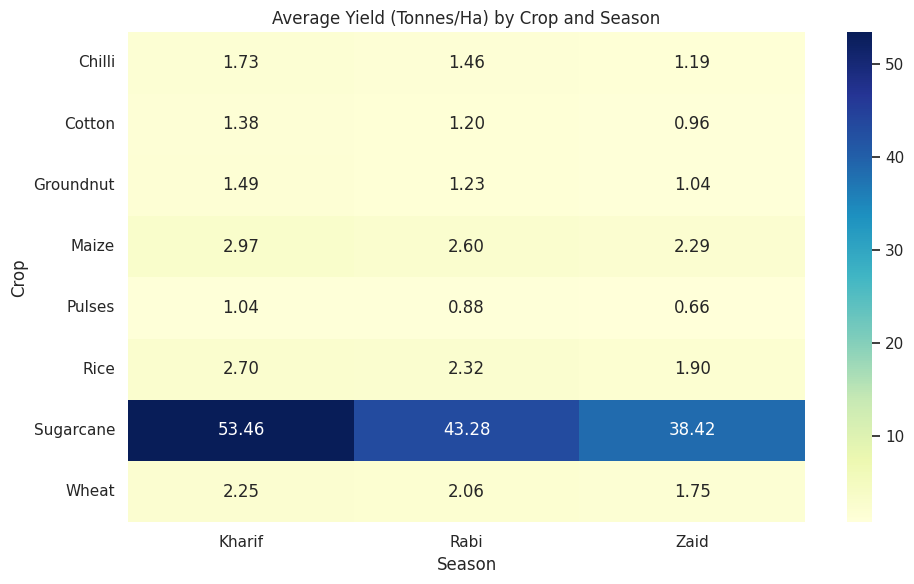

In [108]:
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield (Tonnes/Ha) by Crop and Season")
plt.tight_layout()
plt.show()

In [109]:
state_season_profit = data_df.pivot_table(index="State", columns="Season",
                                           values="Profit_INR", aggfunc="mean").round(0)
state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


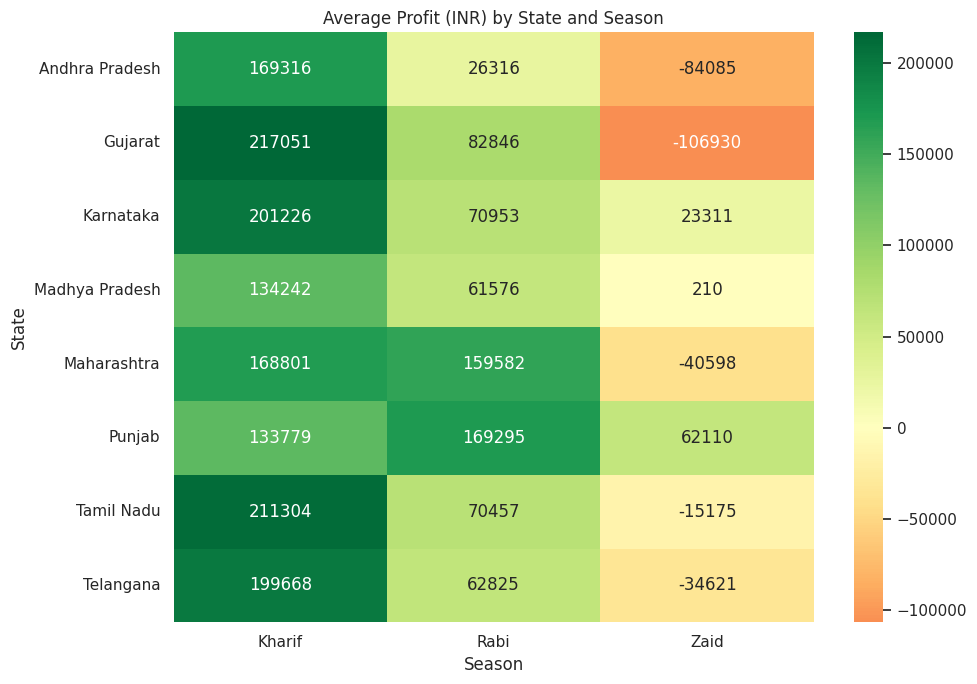

In [110]:
plt.figure(figsize=(10, 7))
sns.heatmap(state_season_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit (INR) by State and Season")
plt.tight_layout()
plt.show()

## 14. Unusual / Unexpected Seasonal Patterns

Investigating notable anomalies in the dataset — most strikingly, the high share of loss-making farms.

In [111]:
loss_by_season = data_df.groupby("Season").apply(
    lambda g: (g["Profit_INR"] < 0).mean() * 100
).round(1)
print("Percent of loss-making farms by season:")
loss_by_season

Percent of loss-making farms by season:


/tmp/ipykernel_3800/2141609208.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_by_season = data_df.groupby("Season").apply(


,0
Season,
Kharif,42.2
Rabi,51.1
Zaid,64.5


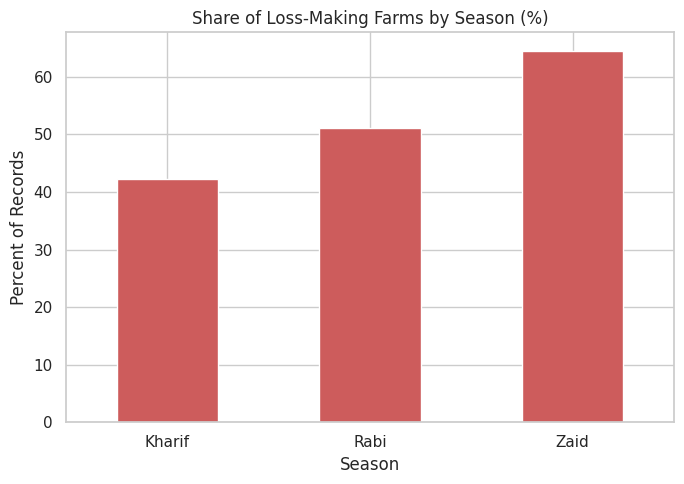

In [112]:
plt.figure(figsize=(7, 5))
loss_by_season.plot(kind="bar", color="indianred")
plt.title("Share of Loss-Making Farms by Season (%)")
plt.ylabel("Percent of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

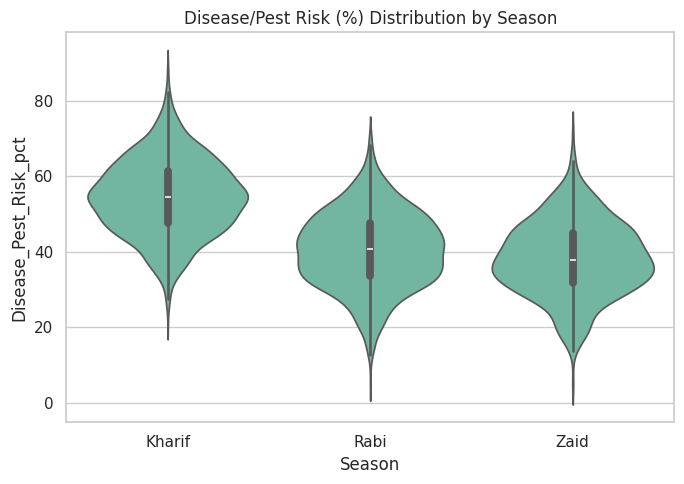

In [113]:
# Disease/pest risk vs season - another environmental risk factor
plt.figure(figsize=(7, 5))
sns.violinplot(data=data_df, x="Season", y="Disease_Pest_Risk_pct")
plt.title("Disease/Pest Risk (%) Distribution by Season")
plt.tight_layout()
plt.show()

In [118]:
# Which crops are profitable across all three seasons vs only some?
crop_season_profit = data_df.pivot_table(index="Crop", columns="Season", values="Profit_INR", aggfunc="mean")
crop_season_profit["Profitable_All_Seasons"] = (crop_season_profit > 0).all(axis=1)
crop_season_profit.sort_values("Profitable_All_Seasons", ascending=False)

Season,Kharif,Rabi,Zaid,Profitable_All_Seasons
Crop,,,,
Chilli,9.543804e+05,638572.496933,448659.093750,True
Sugarcane,1.000791e+06,731612.860465,583635.803922,True
Cotton,2.169995e+05,107343.587065,-53925.336957,False
Groundnut,1.082654e+05,10416.542373,-68872.500000,False
Maize,-3.933267e+04,-89133.403433,-194049.166667,False
Pulses,4.333890e+04,-14309.136150,-139227.806452,False
Rice,-6.490340e+04,-98427.868613,-227239.343137,False
Wheat,-1.058719e+05,-119954.565401,-193208.952941,False


## 15. Key Findings & Insights


- **Seasonal yield differences:** Kharif shows the highest average yield at 5.63 t/ha, about 21% higher than Zaid's 4.64 t/ha (Rabi sits in between at 5.04 t/ha). However, the ANOVA test returned p = 0.2116, which is well above the 0.05 threshold — so this yield gap is not statistically significant and could plausibly be due to random variation rather than a real seasonal effect.
- **Profitability:** Profitability tells a very different story than yield. Average profit falls from +₹178,915 in Kharif to +₹87,689 in Rabi to -₹24,805 in Zaid — meaning the average Zaid-season farm actually loses money. This is backed by a highly significant ANOVA result (F = 34.292, p < 0.0001). The share of loss-making farms rises steadily too: 42.2% in Kharif, 51.1% in Rabi, 64.5% in Zaid
- **Environmental drivers:** Water efficiency (t per 1000m³) has by far the strongest correlation with yield (r = 0.91) — dramatically higher than every other variable, including Profit (r = 0.49) and all nutrient inputs (Nitrogen, Phosphorus, Potassium all under r = 0.06). Rainfall itself barely correlates with yield (r = 0.029).
- **Resource usage:** Fertilizer, pesticide, and water-used medians stay roughly flat across all three seasons — yet yield and profit still decline sharply into Zaid. Since inputs aren't changing much, the seasonal decline is better explained by environmental conditions: rainfall drops from 852mm (Kharif) to 299mm (Zaid), while average temperature rises to 31°C in Zaid, the hottest of the three seasons.
- **Crop consistency:** The Kharif > Rabi > Zaid yield ordering holds for every single one of the 8 crops with no exceptions — e.g. Sugarcane goes 53.46 → 43.28 → 38.42 t/ha, Rice goes 2.70 → 2.32 → 1.90 t/ha. This confirms the seasonal effect is systemic across the whole dataset, not specific to any one crop.
- **State-level anomaly:** Most states swing to a loss in Zaid season (Gujarat falls as low as -₹106,930, Andhra Pradesh to -₹84,085), but Karnataka (₹23,311), Madhya Pradesh (₹210), and Punjab (₹62,110) stay profitable even in Zaid — an unexpected pattern worth investigating, since it suggests these three states are doing something differently that protects margins in the toughest season.
- **Irrigation mix barely shifts by season:** Despite Zaid having far less rainfall, farmers aren't meaningfully changing irrigation strategy — Flood stays the dominant method at ~32-33% in all three seasons, Drip stays ~23%, Sprinkler ~18-20%. This static irrigation mix, despite changing rainfall, may itself be contributing to Zaid's weaker performance.
- **Rainfall alone doesn't predict yield:** The Rainfall vs Yield scatter plot shows no clean linear relationship — high-yield and low-yield points appear across the full rainfall range in every season. Combined with rainfall's near-zero correlation (r = 0.029), this reinforces insight #3: it's how efficiently water is used, not how much rain falls, that actually drives yield.
## 16. Recommendations

- Recommendation 1: Since water efficiency is overwhelmingly the strongest yield driver (r = 0.91) but irrigation method mix barely changes across seasons, prioritize shifting a larger share of Zaid-season farms toward Drip/Sprinkler irrigation — that's precisely when rainfall is lowest (299mm) and loss rates are highest (64.5%).
- Recommendation 2: Flag Andhra Pradesh, Gujarat, Maharashtra, Tamil Nadu, and Telangana for a Zaid-season cost review, since these are the states swinging into the largest losses. Study Karnataka, Madhya Pradesh, and Punjab's practices specifically, since they stay profitable in Zaid despite the same seasonal conditions — whatever they're doing differently may be transferable.
- Recommendation 3: Since input usage (fertilizer, pesticide, water volume) stays flat across seasons while Total Cost is actually highest in Zaid (₹543,977) and Revenue is lowest (₹519,172), the Zaid-season problem looks like a cost/revenue squeeze rather than an under-application of inputs — investigate cost structure (labor, equipment, transport) before recommending more fertilizer or pesticide.

## 17. Conclusion

This analysis examined seasonal agricultural performance using 4,000 farm records covering 8 states, 8 crops, and 3 agricultural seasons: Kharif, Rabi, and Zaid. Through systematic data cleaning, exploratory data analysis, univariate and bivariate analysis, correlation analysis, and statistical testing, the study identified important variations in crop yield, profitability, resource utilization, and environmental conditions across different seasons and regions.

The findings provide a data-driven understanding of how seasonal and environmental factors influence agricultural performance. These insights can support evidence-based crop selection, resource allocation, productivity improvement, and seasonal farm planning. Overall, the analysis demonstrates how data analytics and statistical techniques can be applied to agricultural datasets to identify meaningful patterns and support more informed decision-making.

## 18. Limitations

- This is a single-year cross-sectional dataset — seasonal patterns can't be validated against year-over-year variability.
- Missing values in Rainfall, Soil Moisture, and Yield were imputed using season-wise medians, which may slightly understate real variability.
- Correlation shows association, not causation — a strong link between water efficiency and yield doesn't prove one causes the other.
- Findings are specific to the 8 states, 8 crops, and 3 seasons in this dataset and may not generalize elsewhere.